# Breast cancer classification: analysis

This notebook is an **add-on** to the original `Cancer_cell_classification.ipynb`, which trained a single Gaussian Naive Bayes model and reported accuracy only (94.1%).

Here the same dataset and the **same train/test split** are used, and the analysis goes further with:

1. a comparison of several classifiers,
2. cross-validated scores instead of a single split,
3. recall and precision for the *malignant* class, which matters more than accuracy in a medical setting,
4. a look at which features drive the predictions.

In this dataset label `0` = malignant and `1` = benign.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # silences a joblib core-count warning on Windows
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
SEED = 42
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

data = load_breast_cancer()
X, y = data.data, data.target
print("samples:", X.shape[0], "| features:", X.shape[1])
print(pd.Series(y).map(dict(enumerate(data.target_names))).value_counts())

samples: 569 | features: 30
benign       357
malignant    212
Name: count, dtype: int64


## 1. Model comparison on the original split

Same split as the original notebook (`test_size=0.33, random_state=42`), so the Gaussian Naive Bayes row reproduces the original 94.1% accuracy. *Malignant* is treated as the positive class.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

models = {
    "Gaussian Naive Bayes (original)": GaussianNB(),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(probability=True, random_state=SEED)),
    "k-NN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
}

rows = []
fitted = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    fitted[name] = m
    pred = m.predict(X_test)
    proba_malignant = m.predict_proba(X_test)[:, 0]
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision (malignant)": precision_score(y_test, pred, pos_label=0),
        "recall (malignant)": recall_score(y_test, pred, pos_label=0),
        "F1 (malignant)": f1_score(y_test, pred, pos_label=0),
        "ROC-AUC": roc_auc_score(1 - y_test, proba_malignant),
    })
results = pd.DataFrame(rows).set_index("model").round(4)
results.sort_values("F1 (malignant)", ascending=False)

,accuracy,precision (malignant),recall (malignant),F1 (malignant),ROC-AUC
model,,,,,
Logistic Regression,0.9787,0.9565,0.9851,0.9706,0.9973
SVM (RBF),0.9681,0.9420,0.9701,0.9559,0.9962
k-NN (k=5),0.9574,0.9403,0.9403,0.9403,0.9783
Random Forest,0.9574,0.9538,0.9254,0.9394,0.9957
Gaussian Naive Bayes (original),0.9415,0.9242,0.9104,0.9173,0.9912


## 2. Cross-validation

A single split of 188 test samples is noisy: one extra mistake moves accuracy by about 0.5 points. Stratified 5-fold cross-validation on the full dataset gives a more reliable ranking.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, m in models.items():
    s = cross_validate(m, X, y, cv=cv, scoring=["accuracy", "roc_auc"])
    cv_rows.append({"model": name,
                    "CV accuracy": s["test_accuracy"].mean(), "± std": s["test_accuracy"].std(),
                    "CV ROC-AUC": s["test_roc_auc"].mean()})
cv_results = pd.DataFrame(cv_rows).set_index("model").round(4)
cv_results.sort_values("CV accuracy", ascending=False)

,CV accuracy,± std,CV ROC-AUC
model,,,
SVM (RBF),0.9772,0.0163,0.9945
Logistic Regression,0.9737,0.0166,0.9953
k-NN (k=5),0.9631,0.0179,0.9849
Random Forest,0.9526,0.0131,0.9895
Gaussian Naive Bayes (original),0.9385,0.0235,0.9887


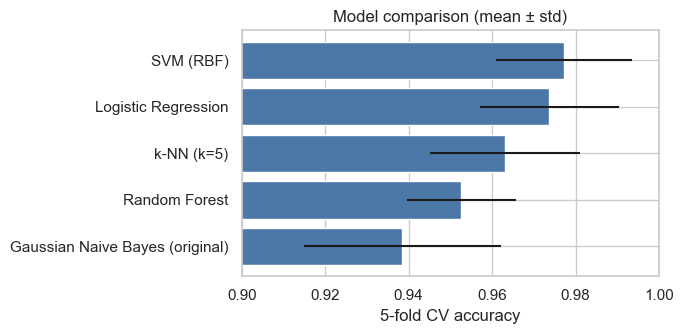

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
order = cv_results.sort_values("CV accuracy")
ax.barh(order.index, order["CV accuracy"], xerr=order["± std"], color="#4C78A8")
ax.set_xlim(0.9, 1.0)
ax.set_xlabel("5-fold CV accuracy")
ax.set_title("Model comparison (mean ± std)")
plt.tight_layout(); plt.show()

## 3. Error analysis of the best model

In cancer screening a **false negative** (a malignant tumour predicted benign) is far worse than a false positive. The confusion matrix and the per-class report show how the best model behaves on exactly that.

Best model on the held-out split: Logistic Regression 

              precision    recall  f1-score   support

   malignant      0.957     0.985     0.971        67
      benign      0.992     0.975     0.983       121

    accuracy                          0.979       188
   macro avg      0.974     0.980     0.977       188
weighted avg      0.979     0.979     0.979       188



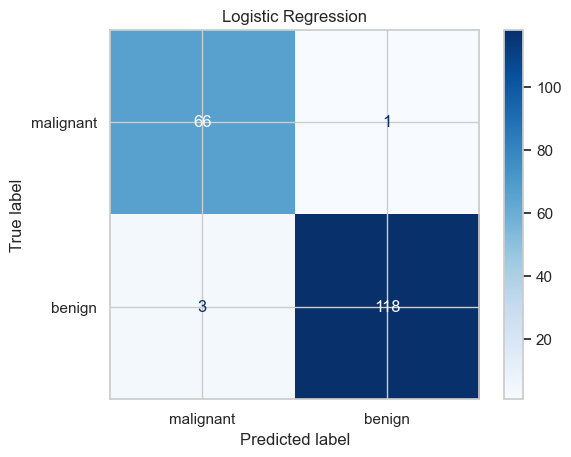

In [5]:
best_name = results["F1 (malignant)"].idxmax()
best = fitted[best_name]
pred = best.predict(X_test)
print("Best model on the held-out split:", best_name, "\n")
print(classification_report(y_test, pred, target_names=data.target_names, digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=data.target_names).plot(cmap="Blues")
plt.title(best_name); plt.show()

## 4. Which features matter?

Random Forest impurity-based importances, top 10 features.

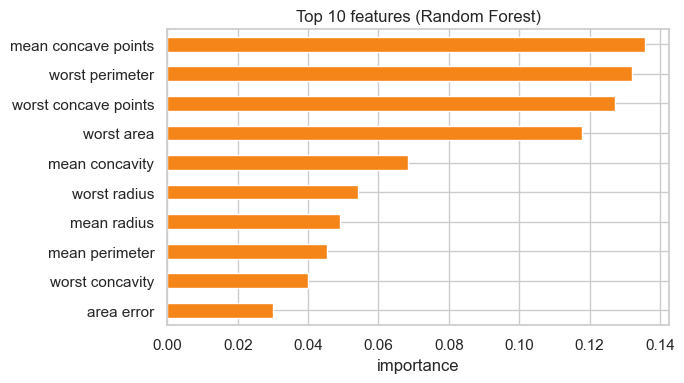

In [6]:
rf = fitted["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=data.feature_names).sort_values().tail(10)
imp.plot.barh(figsize=(7, 4), color="#F58518")
plt.xlabel("importance"); plt.title("Top 10 features (Random Forest)")
plt.tight_layout(); plt.show()

## Conclusions

- On the original split, **Logistic Regression** (with scaling) beats the original Gaussian Naive Bayes: accuracy 97.9% vs 94.1%, and recall on the malignant class 98.5% vs 91.0%. That is **1 missed malignant case instead of 6** out of 67.
- Cross-validation confirms the direction: SVM (97.7%) and Logistic Regression (97.4%) lead, Naive Bayes is last (93.9%). The top two are within one standard deviation of each other, so they should be treated as tied.
- Scaling matters for the distance- and margin-based models; Naive Bayes and Random Forest do not need it but score lower here.

**Caveats:** only 569 samples (188 in the test split), so differences of one or two predictions are noise; this is a teaching dataset, not a clinical tool.